# **I. Supervised Learning Evaluation & Train-Test Split**
* **Purpose:** Evaluates how well a trained machine learning model generalizes to **unseen data**. It involves comparing the model's predictions directly against the "ground truth" (actual labels).
* **Train-Test Split Technique:** Prevents the model from simply memorizing the dataset. 
  * **Training Set (70-80%):** The subset of data used to train and optimize the algorithm.
  * **Test Set (20-30%):** The withheld subset used exclusively to evaluate predictive performance on new data.

## **1/ The Confusion Matrix**
A foundational table that breaks down the exact counts of correct and incorrect predictions made by a classifier. 
* **True Positive (TP):** Model predicted positive, and the actual label is positive (e.g., Predicted Pass, Actually Pass).
* **True Negative (TN):** Model predicted negative, and the actual label is negative (e.g., Predicted Fail, Actually Fail).
* **False Positive (FP) / Type I Error:** Model predicted positive, but the actual label is negative (e.g., Predicted Pass, Actually Fail).
* **False Negative (FN) / Type II Error:** Model predicted negative, but the actual label is positive (e.g., Predicted Fail, Actually Pass).

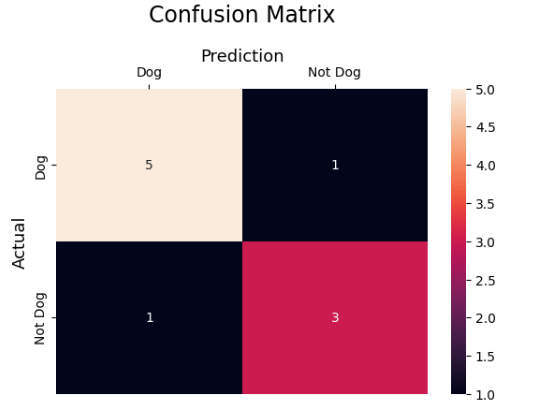
## **2/ Core Classification Metrics**
### **1. Accuracy**
* **Definition:** The overall ratio of correctly predicted instances to the total number of instances.
* **Formula:** (TP + TN) / (Total Instances)
* **When to use:** Great for quick baseline checks, but can be highly misleading if the dataset is imbalanced.

### **2. Precision**
* **Definition:** Out of all the instances the model *predicted* as positive, how many were *actually* positive?
* **Formula:** TP / (TP + FP)
* **Real-World Use Case:** **Movie Recommendations / Ads.** When the cost of a **False Positive is high**. You don't want to waste budget promoting a movie a user has zero interest in (False Positive) because it creates an additional cost with no benefit.

### **3. Recall (Sensitivity)**
* **Definition:** Out of all the *actual* positive instances in the data, how many did the model correctly identify?
* **Formula:** TP / (TP + FN)
* **Real-World Use Case:** **Medical Diagnoses.** When the opportunity cost of a **False Negative is dangerous**. It is vastly better to falsely flag a healthy patient for more testing (False Positive) than to miss diagnosing a sick patient (False Negative).

### **4. F1 Score**
* **Definition:** The harmonic (balanced) mean of Precision and Recall. It provides a single score that balances both concerns.
* **Formula:** 2 * (Precision * Recall) / (Precision + Recall)
* **When to use:** When you are dealing with imbalanced datasets or when you cannot afford to solely optimize for Precision or Recall because **both False Positives and False Negatives carry significant consequences** (e.g., treating a patient for an illness they don't actually have).

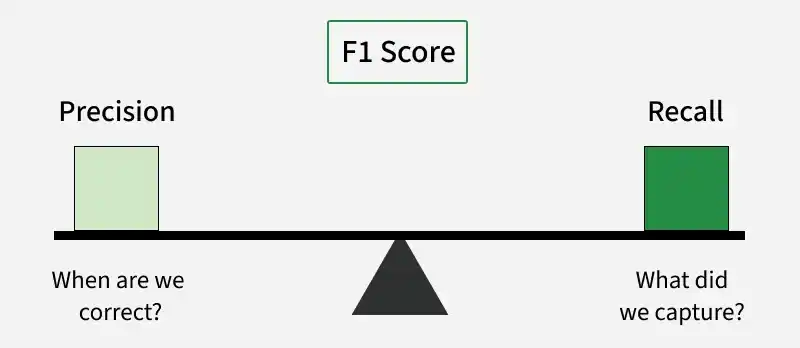

### **5/ Multi-Class Evaluation (The Classification Report)**
When dealing with **multiple classes** (e.g., predicting three types of Iris flowers: setosa, versicolor, virginica), metrics like Precision, Recall, and F1 are calculated independently for *each individual class*. 
* **Support:** The actual number of ground-truth occurrences of each class in the dataset.
* **Weighted Average:** The overall model performance is calculated by averaging the metrics of all classes, weighted by the support of each class to account for class imbalances.

---
# **II. Regression Evaluation**
* **Purpose:** Determines how accurately a regression model predicts continuous numerical values (e.g., exam grades, temperature, revenue). 
* **Model Error:** The calculated difference between the actual data points and the trend line generated by the algorithm (Predicted minus Actual, or $\hat{y}_i - y_i$).
* **Visual Validation:** No single metric provides a universally perfect measure of goodness of fit. Always plot actual vs. predicted values to visually inspect how well the model captures the data's underlying trend.

## **1/ Core Regression Metrics**

| Metric | Full Name | Definition & Characteristics |
| :--- | :--- | :--- |
| **MAE** | Mean Absolute Error | The average absolute difference between the predicted values and the actual observed historical data. |
| **MSE** | Mean Squared Error | The sum of the squared differences between predicted and actual values, divided by the number of historical points (adjusted for the number of model parameters). |
| **RMSE** | Root Mean Squared Error | The square root of the MSE. It is highly popular because it shares the **same units** as the target variable, making its magnitude much easier to interpret than MSE. |
| **$R^2$** | Coefficient of Determination | Measures the proportion (percentage) of variance in the dependent target variable that can be explained by the independent input variables. |

## **2/ Deep Dive: Variance & $R^2$ Score**
* **Total Variance ($\sigma^2$):** Measures how much the actual target values vary from their own mean average.
* **Explained Variance:** The sum of squared differences between the model's predictions and the average value of the actual target data.
* **Interpreting $R^2$ Values:**
  * **$R^2 = 1$:** A perfectly fit model ($\hat{y}_i = y_i$ for all data points). Explained variance perfectly matches total variance; unexplained variance is zero.
  * **$R^2$ between $0$ and $1$:** Typical real-world performance (e.g., an $R^2$ of 0.85 means the model explains 85% of the variation in the outcome).
  * **$R^2 = 0$:** A simplistic baseline model that fails to find any trend and merely predicts the constant mean of the data for every single point.
  * **$R^2 < 0$:** The model performs so poorly that its unexplained variance exceeds the total variance (it is literally worse than just guessing the average).
* **Limitation:** $R^2$ strictly assumes a linear relationship between input and target features. It can be highly misleading when used to evaluate nonlinear models.

## **3/ Improving Model Fit (Data Transformations)**
When dealing with non-linear or highly skewed target variables (e.g., data with an exponential or log-normal distribution), a standard linear model will struggle to fit the data accurately. 
* Applying mathematical transformations to the target variable—specifically a **Logarithmic transformation** or a **Box-Cox transformation**—can normalize the distribution.
* These transformations concentrate the data points much closer to the best-fit line, which visually improves the fit and quantitatively improves all evaluation metrics (raising $R^2$ while lowering MAE, MSE, and RMSE).

---
## The Challenge of Evaluating Unsupervised Learning
* **No Ground Truth:** Unlike supervised learning, unsupervised models (clustering, dimensionality reduction) lack predefined labels, making evaluation inherently subjective.
* **Stability:** A key reliability measure. A stable model produces consistent results and patterns even when the data subset is varied or perturbed.
* **Holistic Approach:** There is no single "best" metric. Effective evaluation requires a combination of mathematical heuristics, visualization tools, and human domain expertise.

## Approaches to Evaluating Clusters
Because there are no definitive labels, practitioners use various heuristics to assess cluster quality:
1. **Internal Evaluation:** Uses only the input data itself to measure cluster geometry.
2. **External Evaluation:** Uses known ground-truth labels (if they happen to be available) to cross-check the model's groupings.
3. **Generalizability / Stability:** Checks cluster consistency across data variations.
4. **Visualization:** Uses dimensionality reduction (PCA, t-SNE) to plot and visually inspect clusters.
5. **Cluster-Assisted Learning:** Feeds the cluster outputs into a supervised learning model to evaluate their predictive usefulness.

---

## 1. Internal Clustering Metrics (No Labels Required)
These metrics evaluate quality based on how tight and well-separated the clusters are.

* **Silhouette Score:** 
  * *Measures:* The cohesion within a cluster compared to its separation from other clusters. It factors in the distance to the nearest neighboring cluster vs. the average distance to other points in the same cluster.
  * *Range:* **-1 to 1**. 
  * *Interpretation:* Higher values (closer to 1) indicate perfectly defined, well-separated clusters. Negative values indicate data points may be assigned to the wrong cluster.
* **Davies-Bouldin Index:** 
  * *Measures:* The average ratio of a cluster's compactness (tightness) to its distance from the nearest neighboring cluster.
  * *Interpretation:* **Lower values are better**, indicating clusters that are highly compact and distinctly separated from one another.
* **Inertia (Used in K-Means):** 
  * *Measures:* The sum of variances within each cluster.
  * *Interpretation:* Lower values mean tighter, more compact clusters. *Tradeoff:* Inertia will always decrease as you increase the number of clusters ($k$), so it must be balanced carefully to avoid overfitting.

---

## 2. External Clustering Metrics (Requires Ground-Truth Labels)
When labeled data is available, these metrics compare the model's unsupervised groupings against the actual known classes.

* **Adjusted Rand Index (ARI):** 
  * *Measures:* The similarity between the true labels and the model's clustering outcomes.
  * *Range:* **-1 to 1**. 
  * *Interpretation:* `1` indicates perfect alignment, `0` indicates completely random clustering, and negative values indicate performance worse than random.
* **Normalized Mutual Information (NMI):** 
  * *Measures:* The amount of shared information between the predicted cluster assignments and the true labels.
  * *Range:* **0 to 1**. 
  * *Interpretation:* `1` indicates perfect agreement; `0` indicates absolutely no shared information.
* **Fowlkes-Mallows Index:** 
  * *Measures:* The geometric mean of Precision and Recall based on the cluster and label assignments.
  * *Interpretation:* A **higher score** indicates better clustering performance and alignment with the true labels.

---

## 3. Evaluating Dimensionality Reduction
When compressing high-dimensional data using PCA, t-SNE, or UMAP, it is critical to measure how much actual information is lost.

* **Explained Variance Ratio (Used in PCA):** 
  * *Measures:* The percentage of the dataset's total variance (information) captured by each principal component.
  * *Usage:* Helps determine exactly how many components are needed to achieve an acceptable "cumulative" explained variance (e.g., dropping components that add negligible variance to simplify the model).
* **Reconstruction Error:** 
  * *Measures:* How accurately the original, high-dimensional data can be rebuilt strictly from the reduced representation.
  * *Interpretation:* **Lower values are better**, indicating high information preservation.
* **Neighborhood Preservation (Crucial for t-SNE & UMAP):** 
  * *Measures:* How well the local relationships (distances between neighboring data points) in the original high-dimensional space are maintained in the new 2D/3D space.

---
## Model Validation & Data Snooping
* **Model Validation:** The process of optimizing a model's hyperparameters without jeopardizing its ability to predict accurately on new, unseen data.
* **Data Snooping (Data Leakage):** The critical error of checking model performance on the *Test Set* while you are still tuning hyperparameters. This causes the model to indirectly overfit the test data, completely invalidating it as a measure of real-world performance.

## The 3-Way Data Split
To prevent data snooping, model tuning must be fully decoupled from the final evaluation. 
1. **Training Set:** Used to initially train the model.
2. **Validation Set:** A designated subset of the training data used exclusively to measure performance *during* the hyperparameter optimization phase.
3. **Test Set:** Completely unseen data held back until the very end, used *only once* for the final model evaluation.

## K-Fold Cross-Validation
Relying on a single, static validation set can lead to overfitting on that specific subset or leave you with too little data for training. 
* **The Process:**
  1. Divide the training dataset into $K$ equal-sized folds (typically 5 or 10).
  2. For a given set of hyperparameters, train the model on $K-1$ folds.
  3. Validate the model on the remaining 1 fold and record the score.
  4. Repeat this process $K$ times, rotating the validation fold each time so every data point is used for both training and validation.
  5. Compute the aggregated (average) score across all folds to determine the best hyperparameter configuration.
* **Benefits:** Maximizes data utilization, smooths out noise unique to any single subset, and provides a much more robust estimate of how the model will generalize.

## Advanced Validation Techniques
* **Stratified Cross-Validation (Classification):** Used for datasets with imbalanced classes. It guarantees that the exact class distribution (the ratio of categories) is preserved across every single validation fold, preventing evaluation bias.
* **Handling Skewed Targets (Regression):** The regression equivalent of an imbalanced dataset is a highly skewed continuous target variable, which violates the normal distribution assumptions of many models.
  * *Solution:* Apply a **Logarithmic** or **Box-Cox transformation** to the target variable to reduce skewness and normalize the distribution before fitting the regression model.

---
## Regularization in Linear Regression
* **Definition:** A regression technique designed to prevent overfitting by constraining the model during training. It achieves this by penalizing and suppressing the size of the model's coefficients (weights).
* **The Regularized Cost Function:** 
  Instead of only minimizing the prediction error, regularization adds a penalty to the loss function:
  $\text{Cost Function} = \text{MSE} + \lambda \times \text{Penalty Term}$
  * $\lambda$ (Lambda): A tuning parameter that controls the influence of the penalty term.

## Regression Methods Compared

| Regression Type | Penalty Term | Key Characteristics & Use Cases |
| :--- | :--- | :--- |
| **Ordinary Linear Regression** | **None** | Optimizes predictions solely by minimizing MSE: $\hat{y} = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$. Highly sensitive to noisy data and outliers. Prone to overfitting because it cannot penalize large coefficients. |
| **Ridge Regression (L2)** | **L2 Penalty**<br>(Sum of squared coefficients) | Shrinks the size of the coefficients to reduce model complexity, making it much more robust to noise than ordinary linear regression. However, it rarely forces coefficients to exactly zero. |
| **Lasso Regression (L1)** | **L1 Penalty**<br>(Sum of absolute values) | Shrinks coefficients and can force irrelevant feature coefficients down to **exactly zero**. Because it isolates only the variables that significantly contribute, it acts as an excellent **feature selector** and is highly effective for datasets with feature sparsity. |

## Performance in Different Environments (Signal-to-Noise Ratio)
* **High Signal-to-Noise Ratio (Clean Data):** All three methods predict non-zero coefficients reasonably well. Lasso precisely finds the zero coefficients, while linear and ridge regression struggle slightly to zero them out.
* **Low Signal-to-Noise Ratio (Noisy Data):** 
  * *Linear Regression:* Performs very poorly. It overfits the noise, massively overestimates ideal coefficients, and assigns large weights to features that should be zero.
  * *Ridge Regression:* Performs decently at predicting non-zero coefficients but fails to completely eliminate the impact of zero-value features.
  * *Lasso Regression:* Heavily outperforms the others. It accurately identifies zero coefficients, effectively filtering out the noise. In comparative tests, Lasso produces predictions that track much closer to actual values, resulting in an MSE drastically lower than both Ridge and ordinary Linear Regression.